In [1]:
# Importing dataset and parsing to datetime
import pandas as pd
df = pd.read_excel("Macro-Labour Dataset Final.xlsx", parse_dates=['Date'])

# Set date column as the index
df.set_index('Date', inplace=True)

# Sort by date just to ensure chronological order
df.sort_index(inplace=True)

# Display
df.head()



,ManufacturingJobs,RetailJobs,InformationJobs,ConstructionJobs,EducationHealthJobs,UnemploymentRate,ConsumerSentiment,SP500,GDP,FedFunds,CPI
Date,,,,,,,,,,,
1969-01-01,18432,7154.0,2019,3534,4326,3.4,91.7,103.010002,993.337,6.30,35.7
1969-02-01,18502,7175.2,2025,3575,4348,3.4,98.2,98.129997,993.337,6.61,35.8
1969-03-01,18558,7202.4,2031,3579,4373,3.4,98.2,101.510002,993.337,6.79,36.1
1969-04-01,18554,7224.1,2041,3590,4391,3.4,98.2,103.690002,1009.020,7.41,36.3
1969-05-01,18588,7267.8,2045,3635,4408,3.4,91.5,103.459999,1009.020,8.67,36.4


In [2]:
# Checking for missing values in each column

# Count missing values per column
missing_counts = df.isna().sum()

# Sort descending to see the most affected features first
missing_counts = missing_counts.sort_values(ascending=False)

# Display results
print("Missing Values per Feature:\n")
print(missing_counts)

# Show how many total missing cells exist overall
total_missing = missing_counts.sum()
print(f"\nTotal missing entries in dataset: {total_missing}")


Missing Values per Feature:

ManufacturingJobs      0
RetailJobs             0
InformationJobs        0
ConstructionJobs       0
EducationHealthJobs    0
UnemploymentRate       0
ConsumerSentiment      0
SP500                  0
GDP                    0
FedFunds               0
CPI                    0
dtype: int64

Total missing entries in dataset: 0


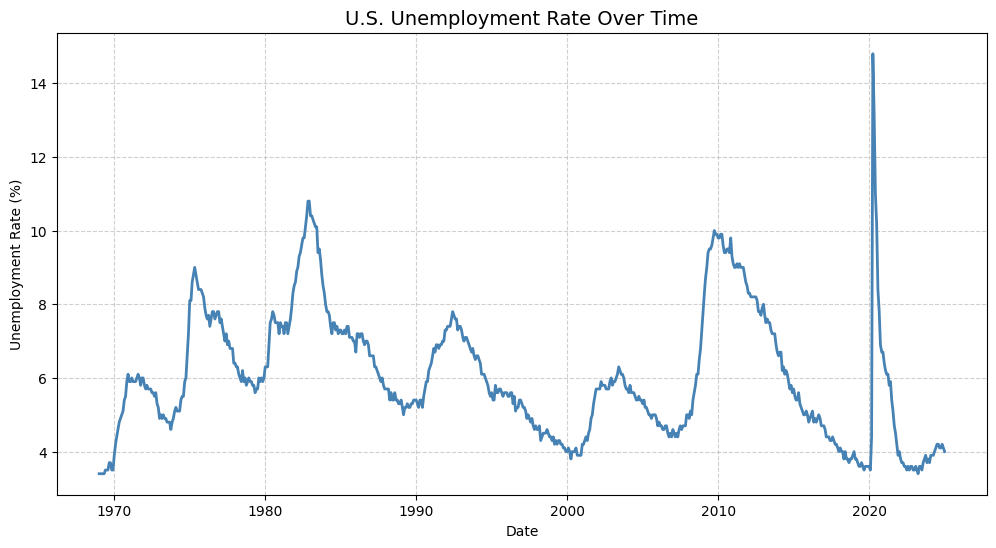

In [3]:
import matplotlib.pyplot as plt

# Plotting the general dataset to see trends and seasonality components
# Noticing a large spike at 2020 (Covid), therefore our test set must end before 2020. Covid would be very difficult to predict looking only at employment and economical factors so we excluded it from the training/test set

# Plot unemployment rate over time
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['UnemploymentRate'], color='steelblue', linewidth=2)
plt.title('U.S. Unemployment Rate Over Time', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


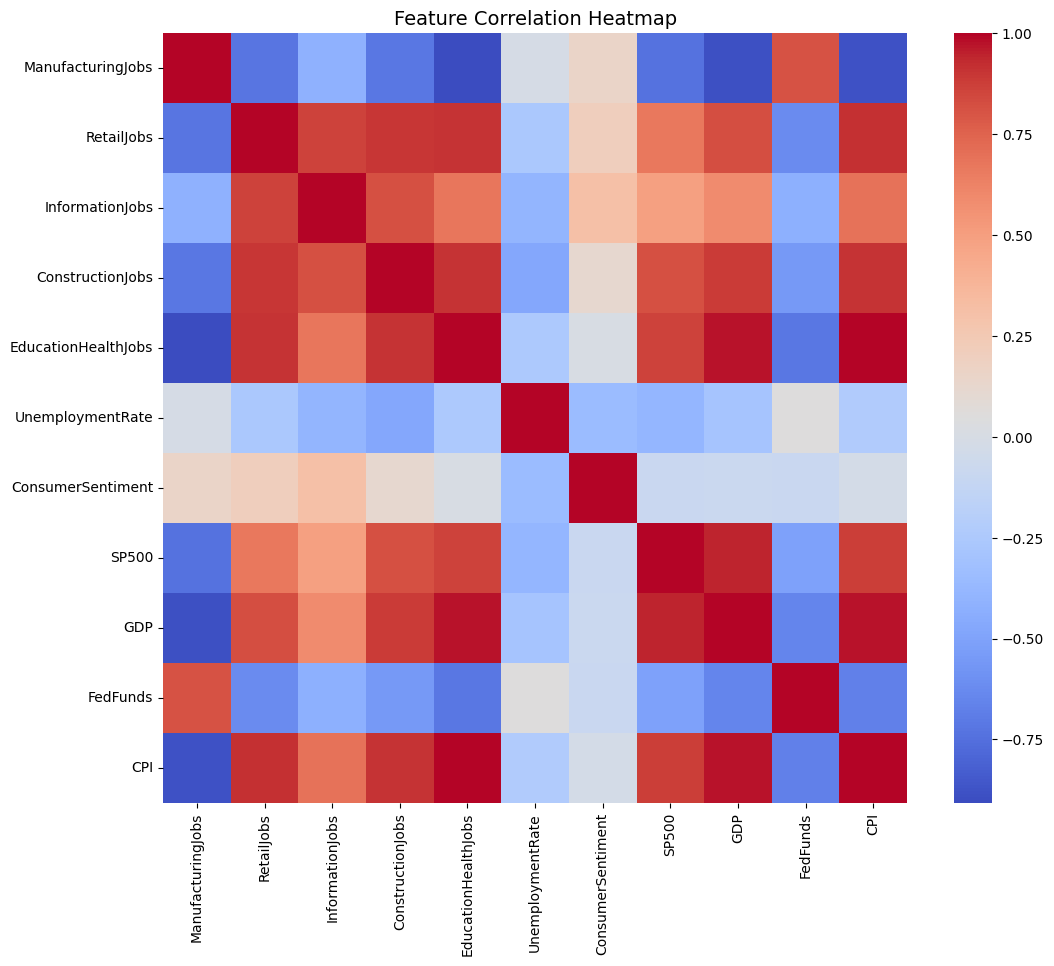


Top correlations with Unemployment Rate:

UnemploymentRate       1.000000
FedFunds               0.048374
ManufacturingJobs     -0.007565
CPI                   -0.229991
EducationHealthJobs   -0.252441
RetailJobs            -0.262218
GDP                   -0.293154
ConsumerSentiment     -0.354357
SP500                 -0.389277
InformationJobs       -0.399526
Name: UnemploymentRate, dtype: float64


In [4]:
import seaborn as sns

# Creating a correlation heatmap to see if we can identify features that have a direct/more-significant relationship with unemployment than others

# Correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), cmap='coolwarm', annot=False)
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.show()

# Printing the top correlations with unemployment rate
target_corr = df.corr()['UnemploymentRate'].sort_values(ascending=False)
print("\nTop correlations with Unemployment Rate:\n")
print(target_corr.head(10))


In [5]:
# Testing to see if the dataset is stationary using ADF

import pandas as pd
from statsmodels.tsa.stattools import adfuller

# Ensure monthly frequency
df = df.asfreq('MS')

# Select target variable
y = df['UnemploymentRate'].asfreq('MS').astype(float)

# Run ADF Test
adf_stat, p_value, usedlag, nobs, critical_vals, icbest = adfuller(y.dropna(), autolag='AIC')

# Print results
print("ADF Stationarity Test")
print(f"ADF Statistic : {adf_stat:.4f}")
print(f"p-value        : {p_value:.4f}")
print(f"Used Lags      : {usedlag}")
print(f"Number of Obs  : {nobs}")
print("Critical Values:")
for key, value in critical_vals.items():
    print(f"   {key}: {value:.4f}")

# Interpretation
if p_value < 0.05:
    print("\n The series is stationary (reject null hypothesis of unit root).")
else:
    print("\n The series is not stationary (fail to reject null hypothesis).")


ADF Stationarity Test
ADF Statistic : -3.4200
p-value        : 0.0103
Used Lags      : 2
Number of Obs  : 670
Critical Values:
   1%: -3.4401
   5%: -2.8659
   10%: -2.5691

 The series is stationary (reject null hypothesis of unit root).


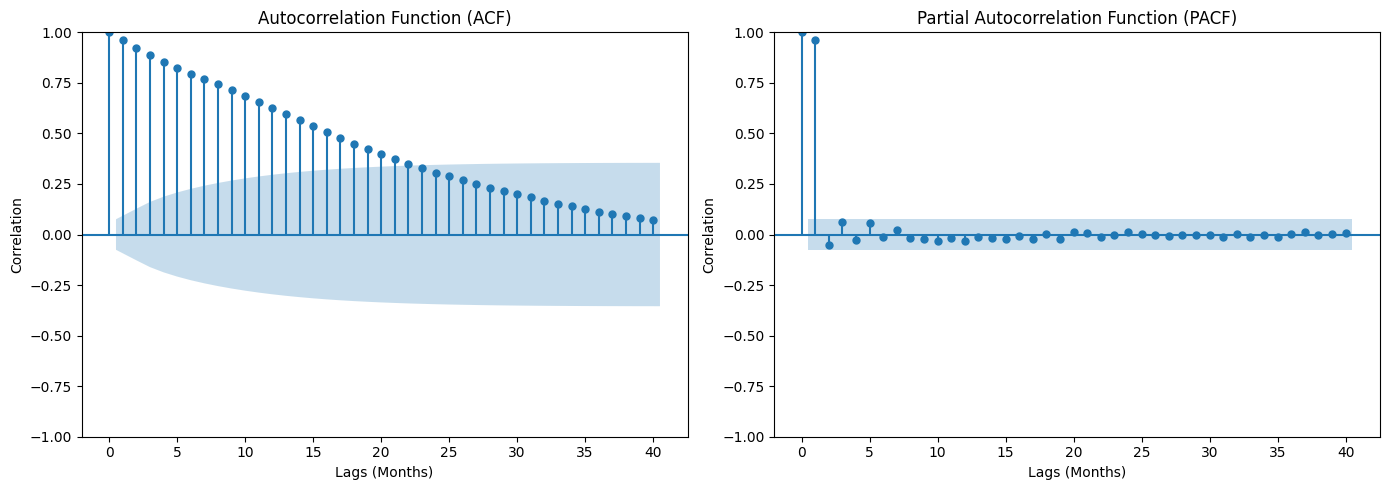

In [6]:
# ACF and PACF plots

import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Ensure monthly frequency
df = df.asfreq('MS')
y = df['UnemploymentRate'].asfreq('MS').astype(float)

# Plot Autocorrelation (ACF) and Partial Autocorrelation (PACF)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Autocorrelation Function
plot_acf(y, lags=40, ax=axes[0])
axes[0].set_title('Autocorrelation Function (ACF)')
axes[0].set_xlabel('Lags (Months)')
axes[0].set_ylabel('Correlation')

# Partial Autocorrelation Function
plot_pacf(y, lags=40, ax=axes[1], method='ywm')
axes[1].set_title('Partial Autocorrelation Function (PACF)')
axes[1].set_xlabel('Lags (Months)')
axes[1].set_ylabel('Correlation')

plt.tight_layout()
plt.show()


In [7]:
# ARIMA model order selection using AIC values

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA

# Ensure monthly frequency
df = df.asfreq('MS')
y = df['UnemploymentRate'].asfreq('MS').astype(float)

# Define search range for p and q
p_max, q_max = 3, 3

results = []

print("Fitting ARIMA(p,0,q) models\n")

for p in range(p_max + 1):
    for q in range(q_max + 1):
        try:
            model = ARIMA(y, order=(p, 0, q)).fit()
            results.append({
                "order": (p, 0, q),
                "aic": model.aic
            })
        except Exception:
            continue

# Sort by AIC. Lower is better
results_sorted = sorted(results, key=lambda x: x["aic"])[:3]

print(" Top 3 ARIMA Models by AIC")
for i, res in enumerate(results_sorted, 1):
    print(f"{i}) ARIMA{res['order']}  |  AIC = {res['aic']:.2f}")

Fitting ARIMA(p,0,q) models

 Top 3 ARIMA Models by AIC
1) ARIMA(2, 0, 1)  |  AIC = 855.87
2) ARIMA(2, 0, 2)  |  AIC = 857.48
3) ARIMA(3, 0, 1)  |  AIC = 857.49



 ARIMA Performance
RMSE: 3.598 (naive: 0.149)
MAE: 3.139
R²: -2.073
Execution Time: 0.870 sec



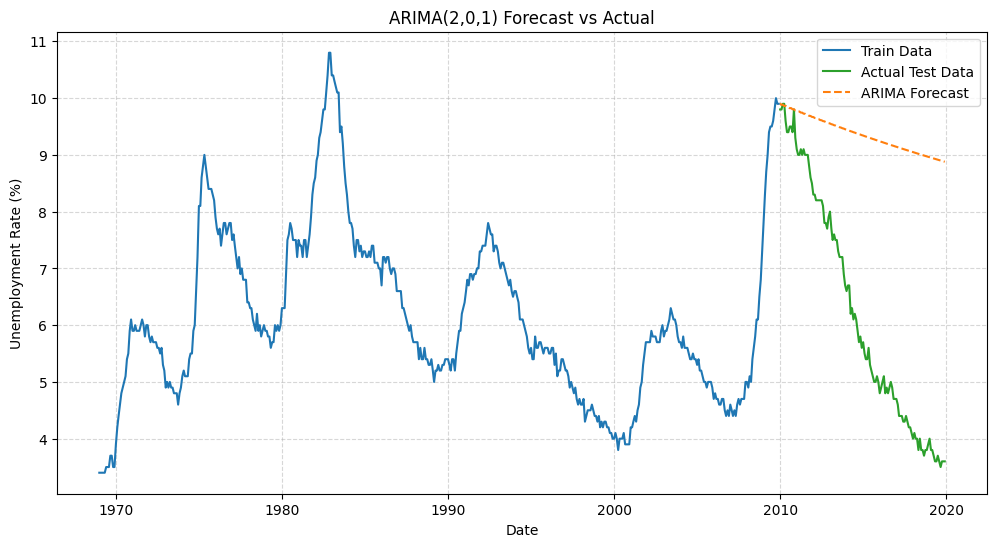

In [8]:
# Uing ARIMA(2,0,1) Forecast — Train: 1969–2009, Test: 2010–2019

import warnings
warnings.filterwarnings("ignore")
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Ensure monthly frequency
df = df.asfreq('MS')
y = df['UnemploymentRate'].asfreq('MS').astype(float)

# Explicit date-based split
train = y.loc['1969-01-01':'2009-12-31']
test  = y.loc['2010-01-01':'2019-12-31']

# Start execution timer
arima_start = time.time()

# Fit ARIMA(2,0,1)
model = ARIMA(train, order=(2, 0, 1))
fit = model.fit()

# Forecast on test period
forecast = fit.forecast(steps=len(test))
forecast.index = test.index

# End Timer
arima_time = time.time() - arima_start

# Naive Forecast Comparison
naive = test.copy()
naive[1:] = test[:-1]     # naive(t) = actual(t-1), first value uses last training point
naive.iloc[0] = train.iloc[-1]

# Calculate RMSE for Naive Model
rmse_naive = np.sqrt(mean_squared_error(test, naive))

# Evaluation Metrics
arima_y_true = test.values
arima_pred   = forecast.values
arima_rmse = np.sqrt(mean_squared_error(arima_y_true, arima_pred))
arima_mae  = mean_absolute_error(arima_y_true, arima_pred)
arima_r2   = r2_score(arima_y_true, arima_pred)
arima_loss = np.nan   # ARIMA has no neural-network loss, therefore store NaN for consistency

print("\n ARIMA Performance")
print(f"RMSE: {arima_rmse:.3f} (naive: {rmse_naive:.3f})")
print(f"MAE: {arima_mae:.3f}")
print(f"R²: {arima_r2:.3f}")
print(f"Execution Time: {arima_time:.3f} sec\n")

# Plot forecast vs actual
plt.figure(figsize=(12,6))
plt.plot(train.index, train, label='Train Data', color='tab:blue')
plt.plot(test.index, test, label='Actual Test Data', color='tab:green')
plt.plot(forecast.index, forecast, label='ARIMA Forecast', color='tab:orange', linestyle='--')
plt.title('ARIMA(2,0,1) Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


In [9]:
# Using Grid Search to find the best SARIMA Model

import warnings, itertools, numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")

# Ensure monthly frequenecy
df = df.asfreq('MS')
y  = df['UnemploymentRate'].astype(float)

train = y.loc['1969-01-01':'2005-12-01']

# Guided compact grids
p, d, q = [1,2], [1], [0,1]          # small p and q to reduce computational cost, forcing d=1 because using macroeconomic time series
P, D, Q = [0,1], [0,1], [0,1]        # tiny seasonal space
s = 12

candidates = []
for (pp, dd, qq, PP, DD, QQ) in itertools.product(p, d, q, P, D, Q):
    candidates.append(((pp, dd, qq), (PP, DD, QQ, s)))

def try_fit(order, seasonal_order):   # Finding best model
    try:
        m = SARIMAX(
            train,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False,
            simple_differencing=True
        ).fit(disp=False, maxiter=200)
        return (order, seasonal_order, m.aic)
    except Exception:
        return None

# Store the best models into results array
results = []
for order, seas in candidates:
    r = try_fit(order, seas)
    if r is not None and np.isfinite(r[2]):
        results.append(r)


# Print results of the search
results_sorted = sorted(results, key=lambda x: x[2])[:3]
print("\n Top 3 SARIMA Models by AIC")
for i, (o, so, aic) in enumerate(results_sorted, 1):
    print(f"{i}) SARIMA{o}x{so}  |  AIC = {aic:.2f}")



 Top 3 SARIMA Models by AIC
1) SARIMA(2, 1, 1)x(0, 0, 0, 12)  |  AIC = -323.61
2) SARIMA(2, 1, 1)x(1, 0, 1, 12)  |  AIC = -323.48
3) SARIMA(2, 1, 1)x(0, 0, 1, 12)  |  AIC = -319.49



 SARIMA Performance
RMSE: 2.975 (naive: 0.149)
MAE: 2.498
R²: -1.100
Execution Time: 1.04 sec


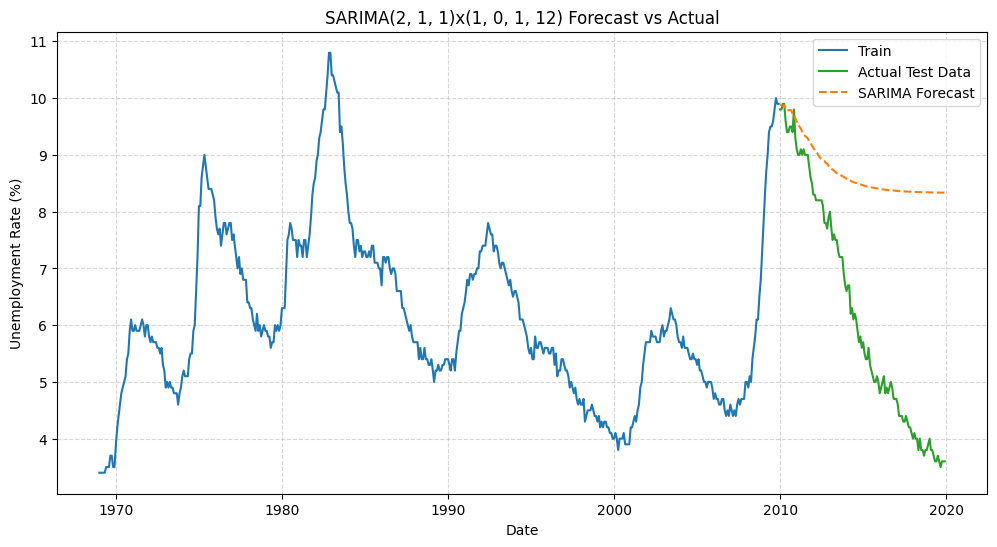

In [10]:
#  Evaluate Best SARIMA Model using test and training set

import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Ensure monthly frequency
df = df.asfreq('MS')
y  = df['UnemploymentRate'].astype(float)

# Specifying Training and Test Dates
train = y.loc['1969-01-01':'2009-12-01']
test  = y.loc['2010-01-01':'2019-12-01']

# Fit best SARIMA from search
best_order = (2, 1, 1)
best_sorder = (1, 0, 1, 12)   # When testing the top 3 models, 2nd best AIC actually turned out to have a better fit than the best AIC

# Start to track execution time
start_time = time.time()

# Fitting model on training data
model = SARIMAX(
    train,
    order=best_order,
    seasonal_order=best_sorder,
    enforce_stationarity=False,
    enforce_invertibility=False
)
fit = model.fit(disp=False)

# Forecast test period
forecast = fit.forecast(steps=len(test))
forecast.index = test.index

# End the execution time
sarima_time = time.time() - start_time

# Calculating Evaluation Metrics
sarima_y_pred = forecast.values
sarima_y_true = test.values
sarima_rmse = np.sqrt(mean_squared_error(test, forecast))
sarima_mae  = mean_absolute_error(test, forecast)
sarima_r2   = r2_score(test, forecast)
sarima_loss = None    # SARIMA has no keras-style loss, therefore store None

# Printing model evaluation
print("\n SARIMA Performance")
print(f"RMSE: {sarima_rmse:.3f} (naive: {rmse_naive:.3f})")
print(f"MAE: {sarima_mae:.3f}")
print(f"R²: {sarima_r2:.3f}")
print(f"Execution Time: {sarima_time:.2f} sec")

# Plot results
plt.figure(figsize=(12,6))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Actual Test Data', color='tab:green')
plt.plot(forecast.index, forecast, label='SARIMA Forecast', color='tab:orange', linestyle='--')
plt.title(f'SARIMA{best_order}x{best_sorder} Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


Train samples: 492
Test  samples: 120
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 

 MLP Performance
RMSE: 1.763 (naive: 0.149)
MAE: 1.568
R²: 0.262
Loss: 0.0003
Execution Time: 8.87 seconds


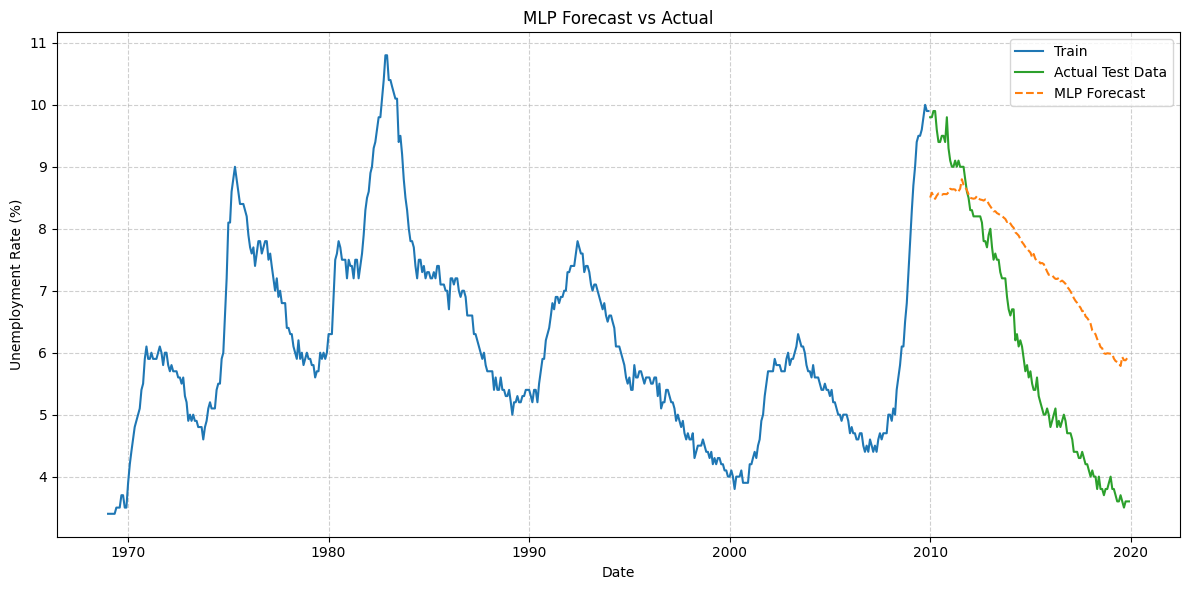

In [11]:
# MLP Model Setup

import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# Ensure monthly frequency
df = df.asfreq('MS')
df = df.select_dtypes(include=[np.number]).dropna()

# Define features and target
X = df.drop(columns=['UnemploymentRate']).values
y = df['UnemploymentRate'].values.reshape(-1, 1)

# Scale features to 0–1 range
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)


# Train/test split using explicit date ranges

train_mask = (df.index >= '1969-01-01') & (df.index <= '2009-12-31')
test_mask  = (df.index >= '2010-01-01') & (df.index <= '2019-12-31')

X_train, X_test = X_scaled[train_mask], X_scaled[test_mask]
y_train, y_test = y_scaled[train_mask], y_scaled[test_mask]

print(f"Train samples: {len(X_train)}")
print(f"Test  samples: {len(X_test)}")

# Start Tracking Execution Time
mlp_start = time.time()

# Building and training the MLP
mlp = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)  # output layer
])

mlp.compile(optimizer='adam', loss='mse')

# Train the model
history_mlp = mlp.fit(X_train, y_train,
                  epochs=50, batch_size=16,
                  validation_split=0.1, verbose=0)


# Predictions
y_pred_scaled = mlp.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_true = scaler_y.inverse_transform(y_test)

# End the time tracking
mlp_time = time.time() - mlp_start

# Result metrics
mlp_pred_scaled = mlp.predict(X_test)
mlp_y_pred = scaler_y.inverse_transform(mlp_pred_scaled)
mlp_y_true = scaler_y.inverse_transform(y_test)

mlp_rmse = np.sqrt(mean_squared_error(mlp_y_true, mlp_y_pred))
mlp_mae  = mean_absolute_error(mlp_y_true, mlp_y_pred)
mlp_r2   = r2_score(mlp_y_true, mlp_y_pred)
mlp_loss = float(history_mlp.history["loss"][-1])

print("\n MLP Performance")
print(f"RMSE: {mlp_rmse:.3f} (naive: {rmse_naive:.3f})")
print(f"MAE: {mlp_mae:.3f}")
print(f"R²: {mlp_r2:.3f}")
print(f"Loss: {mlp_loss:.4f}")
print(f"Execution Time: {mlp_time:.2f} seconds")

# Extracting timestamps where training and testing happen
test_dates = df.index[test_mask]
train_dates = df.index[train_mask]

# Flatten arrays for plotting
y_true_flat = y_true.flatten()
y_pred_flat = y_pred.flatten()

# Plotting the results
full_unemp = df['UnemploymentRate'].values
plt.figure(figsize=(12,6))
plt.plot(train_dates, full_unemp[train_mask], color='tab:blue', label='Train')
plt.plot(test_dates, y_true_flat, color='tab:green', label='Actual Test Data')
plt.plot(test_dates, y_pred_flat, color='tab:orange', linestyle='--', label='MLP Forecast')

# Titles and labels
plt.title('MLP Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


Train sequences: 481 | Test sequences: 120 | Features: 11

LSTM Forecast Performance
RMSE: 0.589 (naive: 0.148)
MAE: 0.509
R²: 0.918
Loss: 0.0013
Execution Time: 25.57 seconds


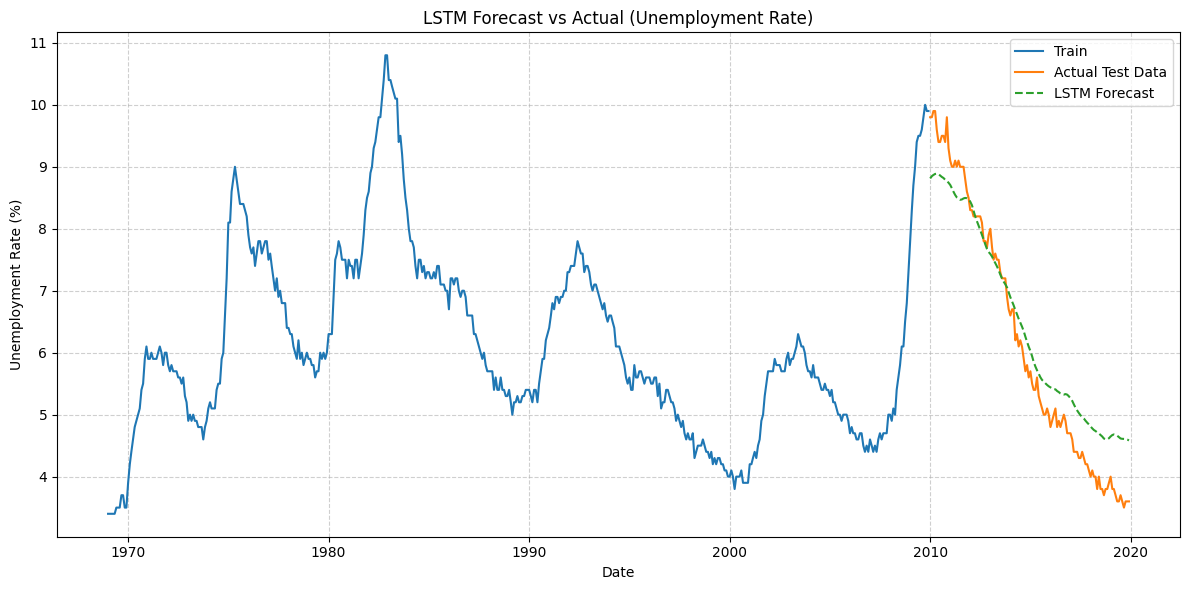

In [17]:
# LSTM Model Setup

import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt

# Model Configuration
LOOKBACK = 12
EPOCHS = 80
BATCH = 16
VAL_SPLIT = 0.15
PATIENCE = 12
TRAIN_START = '1969-01-01'
TRAIN_END   = '2009-12-31'
TEST_START  = '2010-01-01'
TEST_END    = '2019-12-31'

# Seeds
np.random.seed(42)
tf.random.set_seed(42)

# Data checks
if 'df' not in globals():
    raise NameError("DataFrame `df` not found.")
if not isinstance(df.index, pd.DatetimeIndex):
    raise TypeError("`df` must have a DatetimeIndex.")

# Ensure monthly frequency
df = df.asfreq('MS')
df = df.select_dtypes(include=[np.number]).dropna()
if 'UnemploymentRate' not in df.columns:
    raise KeyError("Column 'UnemploymentRate' not found.")

# Features, always including the target as a channel
y = df['UnemploymentRate'].values.reshape(-1, 1)
exog_cols = [c for c in df.columns if c != 'UnemploymentRate']
X_exog = df[exog_cols].values if len(exog_cols) > 0 else np.empty((len(df), 0))
X_all = np.hstack([X_exog, y])  # [exogenous..., lagged target]

# Masks and indices
train_mask = (df.index >= TRAIN_START) & (df.index <= TRAIN_END)
test_mask  = (df.index >= TEST_START)  & (df.index <= TEST_END)
train_idx = np.where(train_mask)[0]

# Train only scaling
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
scaler_X.fit(X_all[train_idx])
scaler_y.fit(y[train_idx])
X_scaled = scaler_X.transform(X_all)
y_scaled = scaler_y.transform(y)

# Sequence builder (target decides split; test may use train history)
def build_sequences(Xs, ys, train_mask, test_mask, lookback):
    Xtr, ytr, tr_idx = [], [], []
    Xte, yte, te_idx = [], [], []
    n = len(ys)
    for t in range(lookback - 1, n):
        s = t - lookback + 1
        if train_mask[t] and train_mask[s:t+1].all():
            Xtr.append(Xs[s:t+1]); ytr.append(ys[t]); tr_idx.append(t)
        elif test_mask[t]:
            Xte.append(Xs[s:t+1]); yte.append(ys[t]); te_idx.append(t)
    return (np.array(Xtr, dtype=np.float32), np.array(ytr, dtype=np.float32),
            np.array(Xte, dtype=np.float32), np.array(yte, dtype=np.float32),
            np.array(tr_idx), np.array(te_idx))

X_train_seq, y_train_seq, X_test_seq, y_test_seq, train_t_idx, test_t_idx = build_sequences(
    X_scaled, y_scaled, train_mask, test_mask, LOOKBACK
)

print(f"Train sequences: {len(X_train_seq)} | Test sequences: {len(X_test_seq)} | Features: {X_train_seq.shape[2]}")

# Build the model
def build_lstm(input_steps, input_feats):
    m = Sequential([
        LSTM(64, return_sequences=True, input_shape=(input_steps, input_feats)),
        Dropout(0.2),
        LSTM(32),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    m.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), loss='mse')
    return m


# Early stopping and setting the minimum learning rate
early = EarlyStopping(monitor='val_loss', patience=PATIENCE, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=6, min_lr=1e-5)

lstm = build_lstm(LOOKBACK, X_train_seq.shape[2])

# Start tracking execution time
lstm_start = time.time()

# Train (no shuffling for time series)
history_lstm = lstm.fit(
    X_train_seq, y_train_seq,
    epochs=EPOCHS,
    batch_size=BATCH,
    validation_split=VAL_SPLIT,
    callbacks=[early, reduce_lr],
    verbose=0,
    shuffle=False
)

# Predictions
lstm_pred_scaled = lstm.predict(X_test_seq, verbose=0)
lstm_y_pred = scaler_y.inverse_transform(lstm_pred_scaled)
lstm_y_true = scaler_y.inverse_transform(y_test_seq)

# End execution time
lstm_time = time.time() - lstm_start

# Evaluation Metrics
lstm_rmse = np.sqrt(mean_squared_error(lstm_y_true, lstm_y_pred))
lstm_mae  = mean_absolute_error(lstm_y_true, lstm_y_pred)
lstm_r2   = r2_score(lstm_y_true, lstm_y_pred)
lstm_loss = float(history_lstm.history["loss"][-1])

# Print Metrics
print("\nLSTM Forecast Performance")
print(f"RMSE: {lstm_rmse:.3f} (naive: {rmse_naive:.3f})")
print(f"MAE: {lstm_mae:.3f}")
print(f"R²: {lstm_r2:.3f}")
print(f"Loss: {lstm_loss:.4f}")
print(f"Execution Time: {lstm_time:.2f} seconds")

# Plot
test_dates_seq = df.index[test_t_idx]
plt.figure(figsize=(12,6))
plt.plot(df.index[train_mask], df['UnemploymentRate'].values[train_mask], label='Train')
plt.plot(test_dates_seq, lstm_y_true.flatten(), label='Actual Test Data')
plt.plot(test_dates_seq, lstm_y_pred.flatten(), '--', label='LSTM Forecast')
plt.title('LSTM Forecast vs Actual (Unemployment Rate)')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


Trial 12 Complete [00h 00m 14s]
val_loss: 0.003912095911800861

Best val_loss So Far: 0.003323199925944209
Total elapsed time: 00h 04m 03s

Best hyperparameters found:
  lstm1_units: 80
  dropout1: 0.1
  lstm2_units: 32
  dropout2: 0.2
  dense_units: 8
  learning_rate: 0.002

HPO LSTM Forecast Performance
RMSE: 0.381 (naive: 0.148)
MAE: 0.346
R²: 0.966
Loss: 0.0021
Execution Time: 258.50 seconds


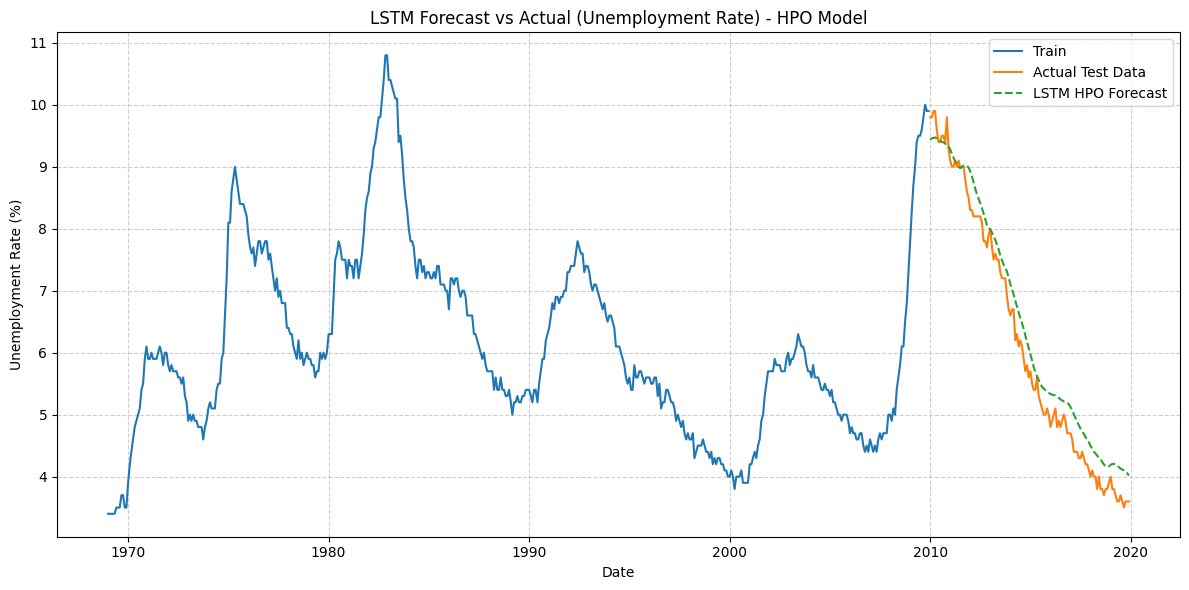

In [13]:
# Refined Hyperparameter Optimization for LSTM Model

!pip install keras_tuner --quiet
import os, logging
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"   # hides most INFO and WARNING from TF C++ backend
import tensorflow as tf
tf.get_logger().setLevel(logging.ERROR)    # hide Python-side TF warnings


import keras_tuner as kt
import warnings
warnings.filterwarnings("ignore")

# Defining the model
def build_lstm_hpo(hp: kt.HyperParameters):
    model = Sequential()

    # First LSTM layer: around 64 units, similar to original model because we know that one is successful
    lstm1_units = hp.Int('lstm1_units', min_value=48, max_value=80, step=16)
    model.add(
        LSTM(
            lstm1_units,
            return_sequences=True,
            input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])
        )
    )

    # Dropout after first LSTM to keep some regularization
    dropout1 = hp.Float('dropout1', min_value=0.1, max_value=0.3, step=0.1)
    model.add(Dropout(dropout1))

    # Second LSTM layer: around 32 units, similar to original model
    lstm2_units = hp.Int('lstm2_units', min_value=24, max_value=40, step=8)
    model.add(
        LSTM(
            lstm2_units,
            return_sequences=False
        )
    )

    # Second dropout: small, but not zero
    dropout2 = hp.Float('dropout2', min_value=0.1, max_value=0.3, step=0.1)
    model.add(Dropout(dropout2))

    # Dense layer: around 16 units, similar to original model
    dense_units = hp.Int('dense_units', min_value=8, max_value=24, step=8)
    model.add(Dense(dense_units, activation='relu'))

    # Output layer
    model.add(Dense(1))

    # Learning rate: changing learning rate marginally to see if we can get better performance with a different value
    lr = hp.Choice('learning_rate', values=[5e-4, 1e-3, 2e-3])

    # Compiling the model
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='mse'
    )
    return model


# New Bayesian tuner to search every combination of hyperparameters to find optimal model
tuner = kt.BayesianOptimization(
    hypermodel=build_lstm_hpo,
    objective='val_loss',
    max_trials=12,
    num_initial_points=4,
    directory='lstm_hpo',
    project_name='unemployment_lstm'
)

# Early stopping and setting minimum learning rate
callbacks = [
    EarlyStopping(monitor='val_loss', patience=PATIENCE, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=6, min_lr=1e-5)
]


# Start tracking execution time
lstm_hpo_start = time.time()

# Run search (still no shuffling because time series)
tuner.search(
    X_train_seq,
    y_train_seq,
    epochs=EPOCHS,
    batch_size=BATCH,
    validation_split=VAL_SPLIT,
    callbacks=callbacks,
    shuffle=False,
    verbose=1
)

# Get best hyperparameters and build/train best model
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
print("\nBest hyperparameters found:")
for k, v in best_hp.values.items():
    print(f"  {k}: {v}")

best_model = tuner.hypermodel.build(best_hp)

best_history = best_model.fit(
    X_train_seq,
    y_train_seq,
    epochs=EPOCHS,
    batch_size=BATCH,
    validation_split=VAL_SPLIT,
    callbacks=callbacks,
    shuffle=False,
    verbose=0
)

# Stop tracking execution
lstm_hpo_time = time.time() - lstm_hpo_start

# Evaluate on test set and compare to naive model
lstm_hpo_pred_scaled = best_model.predict(X_test_seq, verbose=0)
lstm_hpo_y_pred = scaler_y.inverse_transform(lstm_hpo_pred_scaled)
lstm_hpo_y_true = scaler_y.inverse_transform(y_test_seq)

naive = scaler_y.inverse_transform(y_test_seq.copy())
naive[1:] = lstm_hpo_y_true[:-1]

# Metrics
lstm_hpo_rmse = np.sqrt(mean_squared_error(lstm_hpo_y_true, lstm_hpo_y_pred))
lstm_hpo_mae  = mean_absolute_error(lstm_hpo_y_true, lstm_hpo_y_pred)
lstm_hpo_r2   = r2_score(lstm_hpo_y_true, lstm_hpo_y_pred)
lstm_hpo_rmse_naive = np.sqrt(mean_squared_error(lstm_hpo_y_true, naive))
lstm_hpo_loss = float(best_history.history["loss"][-1])

print("\nHPO LSTM Forecast Performance")
print(f"RMSE: {lstm_hpo_rmse:.3f} (naive: {lstm_hpo_rmse_naive:.3f})")
print(f"MAE: {lstm_hpo_mae:.3f}")
print(f"R²: {lstm_hpo_r2:.3f}")
print(f"Loss: {lstm_hpo_loss:.4f}")
print(f"Execution Time: {lstm_hpo_time:.2f} seconds")

# Plot forecast from HPO model
plt.figure(figsize=(12,6))
plt.plot(df.index[train_mask], df['UnemploymentRate'].values[train_mask], label='Train')
test_dates_seq = df.index[test_t_idx]
plt.plot(test_dates_seq, lstm_hpo_y_true.flatten(), label='Actual Test Data')
plt.plot(test_dates_seq, lstm_hpo_y_pred.flatten(), '--', label='LSTM HPO Forecast')
plt.title('LSTM Forecast vs Actual (Unemployment Rate) - HPO Model')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()



GRU Forecast Performance
RMSE: 0.227 (naive: 0.148)
MAE: 0.188
R²: 0.988
Loss: 0.0010
Execution Time: 38.18 seconds


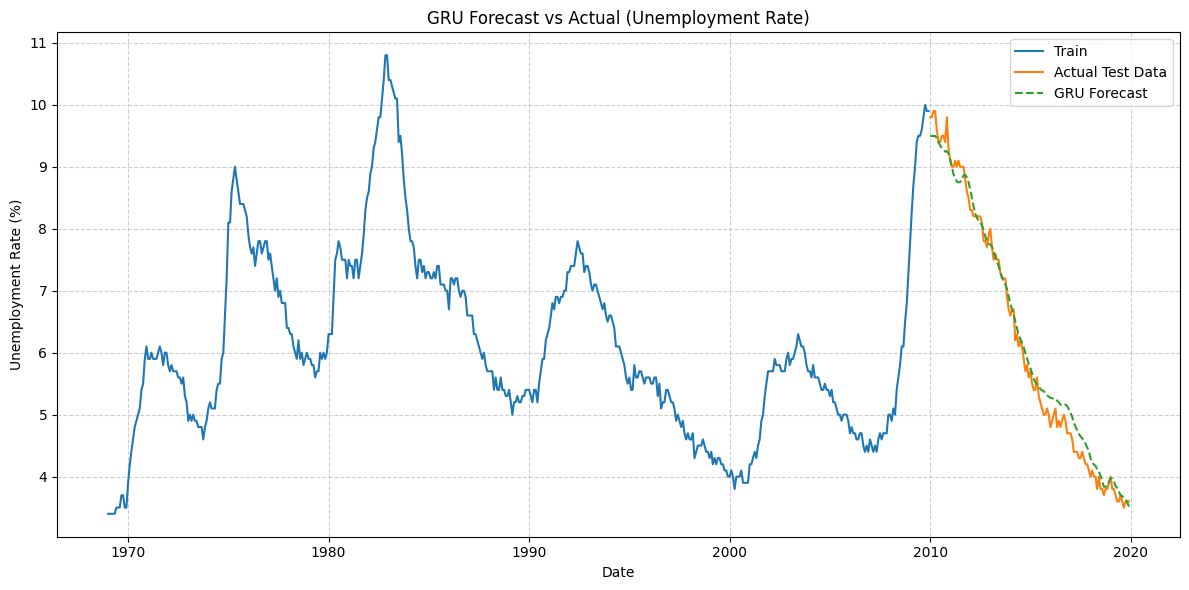

In [14]:
# GRU model Setup
from tensorflow.keras.layers import GRU

# Building the GRU
def build_gru(input_steps, input_feats):
    m = Sequential([
        GRU(64, return_sequences=True, input_shape=(input_steps, input_feats)),
        Dropout(0.2),
        GRU(32),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    m.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), loss='mse')
    return m

gru = build_gru(LOOKBACK, X_train_seq.shape[2])

# Start time tracking
gru_start = time.time()

# Train (no shuffling for time series)
history_gru = gru.fit(
    X_train_seq, y_train_seq,
    epochs=EPOCHS,
    batch_size=BATCH,
    validation_split=VAL_SPLIT,
    callbacks=[early, reduce_lr],
    verbose=0,
    shuffle=False
)

# Predictions
y_pred_gru_scaled = gru.predict(X_test_seq, verbose=0)
y_pred_gru = scaler_y.inverse_transform(y_pred_gru_scaled)
y_true = scaler_y.inverse_transform(y_test_seq)

# End Time Tracking
gru_time = time.time() - gru_start

# Metrics vs naive baseline (last observed value)
naive = scaler_y.inverse_transform(y_test_seq.copy())
naive[1:] = y_true[:-1]  # shift last-obs-forward

# Calculating the evaluation metrics
gru_rmse = np.sqrt(mean_squared_error(y_true, y_pred_gru))
gru_mae  = mean_absolute_error(y_true, y_pred_gru)
gru_r2   = r2_score(y_true, y_pred_gru)
gru_loss = float(history_gru.history["loss"][-1])
rmse_naive = np.sqrt(mean_squared_error(y_true, naive))

# Printing evaluation metrics
print("\nGRU Forecast Performance")
print(f"RMSE: {gru_rmse:.3f} (naive: {rmse_naive:.3f})")
print(f"MAE: {gru_mae:.3f}")
print(f"R²: {gru_r2:.3f}")
print(f"Loss: {gru_loss:.4f}")
print(f"Execution Time: {gru_time:.2f} seconds")

# Plot
test_dates_seq = df.index[test_t_idx]
plt.figure(figsize=(12,6))
plt.plot(df.index[train_mask], df['UnemploymentRate'].values[train_mask], label='Train')
plt.plot(test_dates_seq, y_true.flatten(), label='Actual Test Data')
plt.plot(test_dates_seq, y_pred_gru.flatten(), '--', label='GRU Forecast')
plt.title('GRU Forecast vs Actual (Unemployment Rate)')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Trial 10 Complete [00h 00m 45s]
val_loss: 0.001158782048150897

Best val_loss So Far: 0.0005461717955768108
Total elapsed time: 00h 05m 13s

Best GRU hyperparameters found:
  gru1_units: 80
  dropout1: 0.15000000000000002
  gru2_units: 24
  dropout2: 0.2
  dense_units: 24
  learning_rate: 0.0005

HPO GRU Forecast Performance
RMSE: 0.212 (naive: 0.148)
MAE : 0.164
R²  : 0.989
Loss: 0.0024
Execution Time: 340.20 seconds


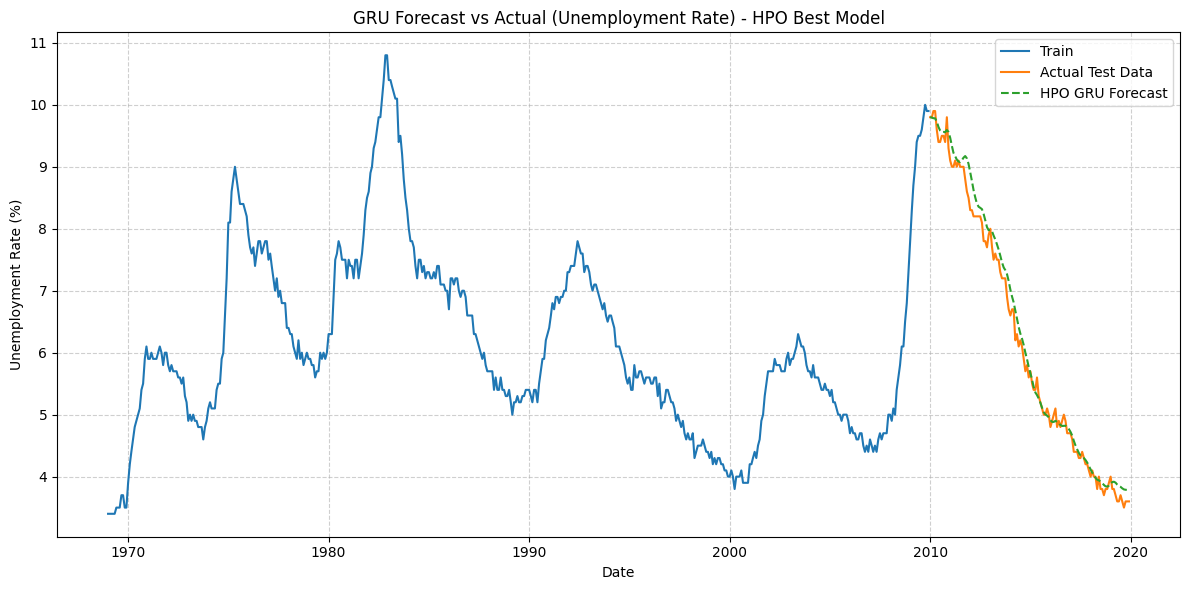

In [15]:
# Hyperparameter Optimization for GRU

from tensorflow.keras.layers import GRU, Dense, Dropout

# Creating the HPO GRU Model
def build_gru_hpo(hp: kt.HyperParameters):
    model = Sequential()

    # First GRU layer: around 64 units, similar to original GRU because we know that one is successful
    gru1_units = hp.Int('gru1_units', min_value=48, max_value=80, step=16)
    model.add(
        GRU(
            gru1_units,
            return_sequences=True,
            input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])
        )
    )

    # Dropout after first GRU layer, test similar values close to original GRU model
    dropout1 = hp.Float('dropout1', min_value=0.1, max_value=0.25, step=0.05)
    model.add(Dropout(dropout1))

    # Second GRU layer: around 32 units, similar to original GRU model
    gru2_units = hp.Int('gru2_units', min_value=24, max_value=40, step=8)
    model.add(
        GRU(
            gru2_units,
            return_sequences=False
        )
    )

    # Second dropout: testing similar values to original GRU model
    dropout2 = hp.Float('dropout2', min_value=0.0, max_value=0.2, step=0.05)
    model.add(Dropout(dropout2))

    # Dense layer, similar values to orginal GRU model
    dense_units = hp.Int('dense_units', min_value=8, max_value=24, step=8)
    model.add(Dense(dense_units, activation='relu'))

    # Output layer
    model.add(Dense(1))

    # Keeping learning rate close to original GRU value
    lr = hp.Choice('learning_rate', values=[5e-4, 1e-3])

    # Compile the HPO model
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='mse'
    )
    return model

# Start tracking execution time
gru_hpo_start = time.time()

# Bayesian tuner to get best GRU parameters
tuner_gru = kt.BayesianOptimization(
    hypermodel=build_gru_hpo,
    objective='val_loss',
    max_trials=10,
    num_initial_points=4,
    directory='gru_hpo',
    project_name='unemployment_gru'
)

callbacks_gru = [early, reduce_lr]

# Run refined HPO search (no shuffling for time series)
tuner_gru.search(
    X_train_seq,
    y_train_seq,
    epochs=EPOCHS,
    batch_size=BATCH,
    validation_split=VAL_SPLIT,
    callbacks=callbacks_gru,
    shuffle=False,
    verbose=1
)

# Get best hyperparameters and build best GRU model
best_hp_gru = tuner_gru.get_best_hyperparameters(num_trials=1)[0]
print("\nBest GRU hyperparameters found:")
for k, v in best_hp_gru.values.items():
    print(f"  {k}: {v}")

best_gru = tuner_gru.hypermodel.build(best_hp_gru)


history_gru_hpo = best_gru.fit(
    X_train_seq,
    y_train_seq,
    epochs=EPOCHS,
    batch_size=BATCH,
    validation_split=VAL_SPLIT,
    callbacks=callbacks_gru,
    shuffle=False,
    verbose=0
)

# Predict on test set
gru_hpo_pred_scaled = best_gru.predict(X_test_seq, verbose=0)
gru_hpo_y_pred = scaler_y.inverse_transform(gru_hpo_pred_scaled)
gru_hpo_y_true = scaler_y.inverse_transform(y_test_seq)

# End timer
gru_hpo_time = time.time() - gru_hpo_start

# Naive baseline
naive = scaler_y.inverse_transform(y_test_seq.copy())
naive[1:] = gru_hpo_y_true[:-1]

# Evaluation metrics
gru_hpo_rmse = np.sqrt(mean_squared_error(gru_hpo_y_true, gru_hpo_y_pred))
gru_hpo_mae  = mean_absolute_error(gru_hpo_y_true, gru_hpo_y_pred)
gru_hpo_r2   = r2_score(gru_hpo_y_true, gru_hpo_y_pred)
gru_hpo_rmse_naive = np.sqrt(mean_squared_error(gru_hpo_y_true, naive))
gru_hpo_loss = float(history_gru_hpo.history["loss"][-1])

# Printing evaluation metrics for HPO GRU
print("\nHPO GRU Forecast Performance")
print(f"RMSE: {gru_hpo_rmse:.3f} (naive: {gru_hpo_rmse_naive:.3f})")
print(f"MAE : {gru_hpo_mae:.3f}")
print(f"R²  : {gru_hpo_r2:.3f}")
print(f"Loss: {gru_hpo_loss:.4f}")
print(f"Execution Time: {gru_hpo_time:.2f} seconds")

# Plot HPO GRU forecast vs actual
plt.figure(figsize=(12,6))
plt.plot(df.index[train_mask], df['UnemploymentRate'].values[train_mask], label='Train')
test_dates_seq = df.index[test_t_idx]
plt.plot(test_dates_seq, gru_hpo_y_true.flatten(), label='Actual Test Data')
plt.plot(test_dates_seq, gru_hpo_y_pred.flatten(), '--', label='HPO GRU Forecast')
plt.title('GRU Forecast vs Actual (Unemployment Rate) - HPO Best Model')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


 Final Model Comparison 



Model,RMSE,MAE,R²,Loss,Execution Time (s)
ARIMA,3.5983,3.1394,-2.0727,nan,0.87
SARIMA,2.9748,2.4984,-1.1001,nan,1.04
MLP,1.7634,1.5680,0.2621,0.0003,8.87
LSTM,0.5893,0.5088,0.9176,0.0013,25.57
HPO LSTM,0.3806,0.3459,0.9656,0.0021,258.50
GRU,0.2273,0.1882,0.9877,0.0010,38.18
HPO GRU,0.2116,0.1643,0.9894,0.0024,340.20


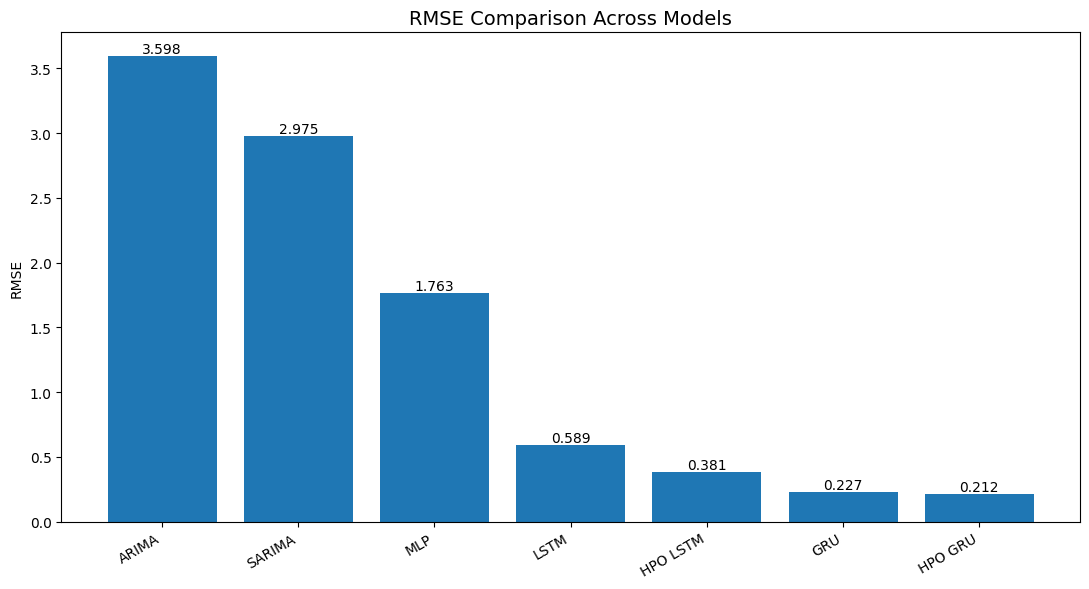

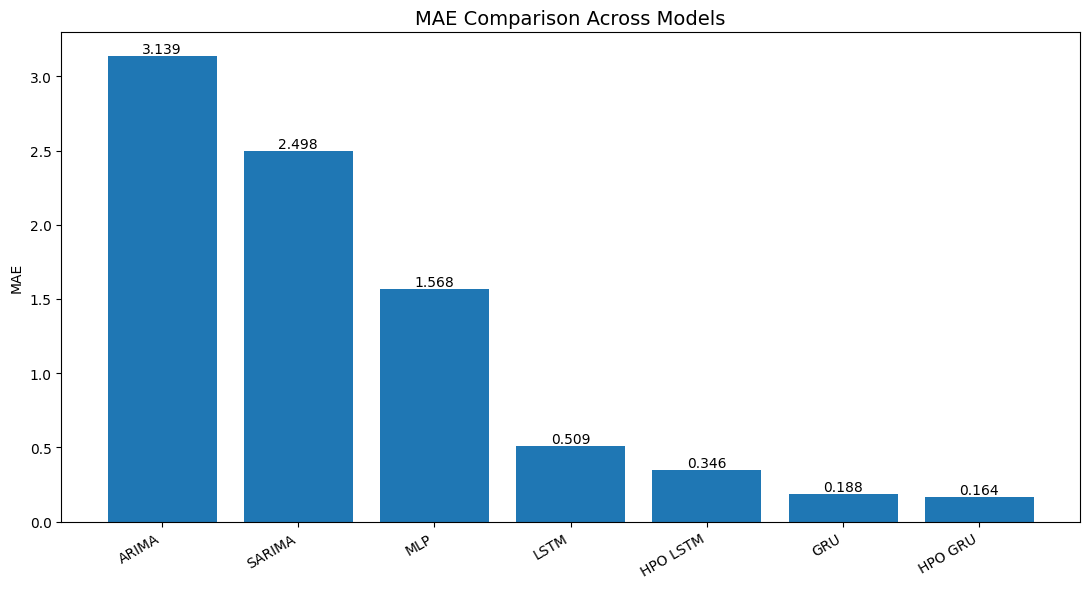

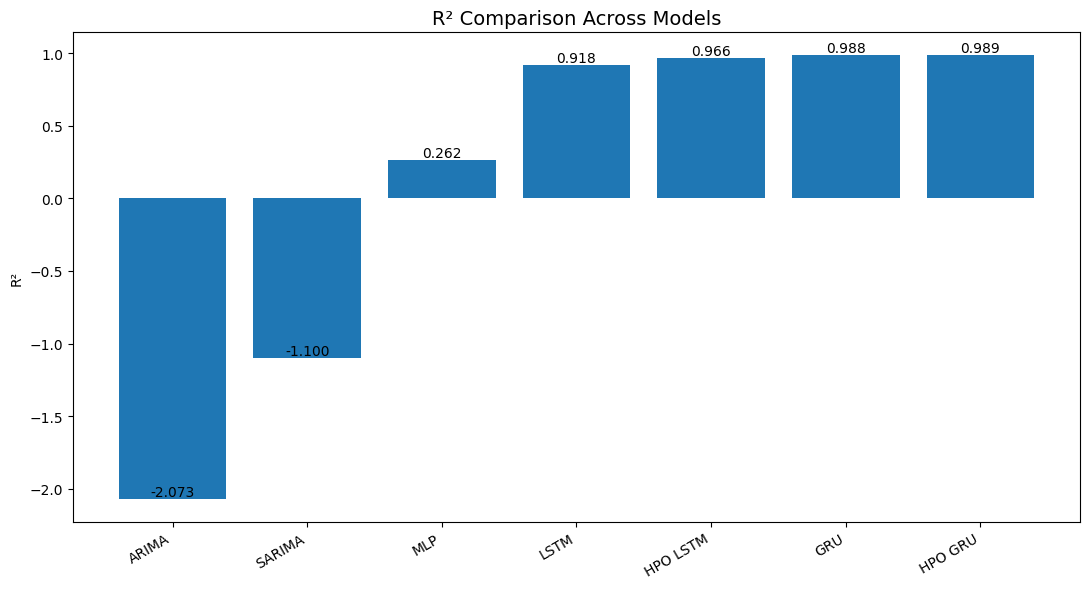

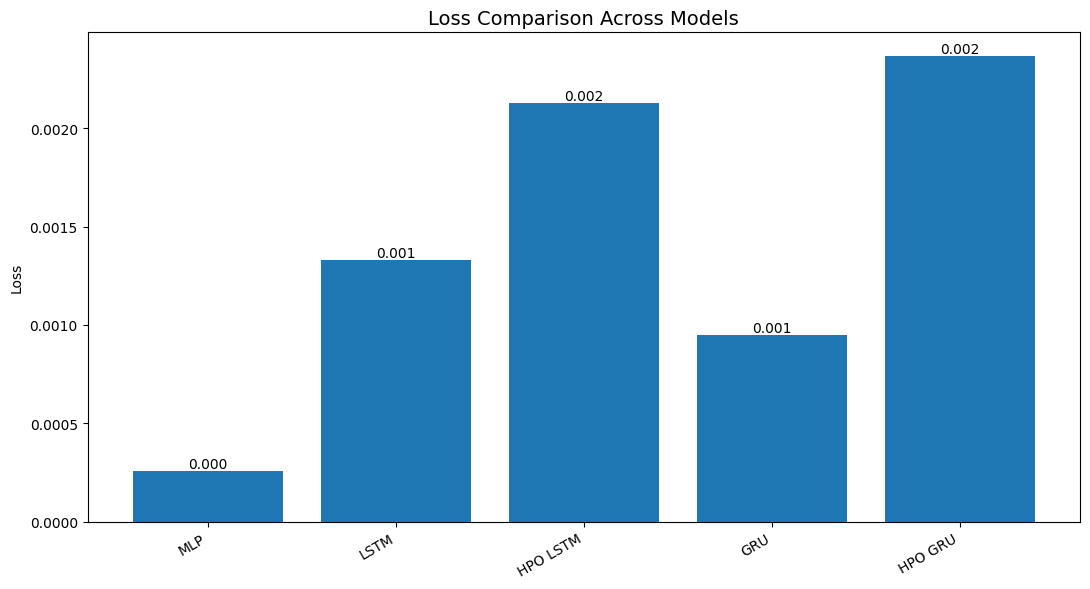

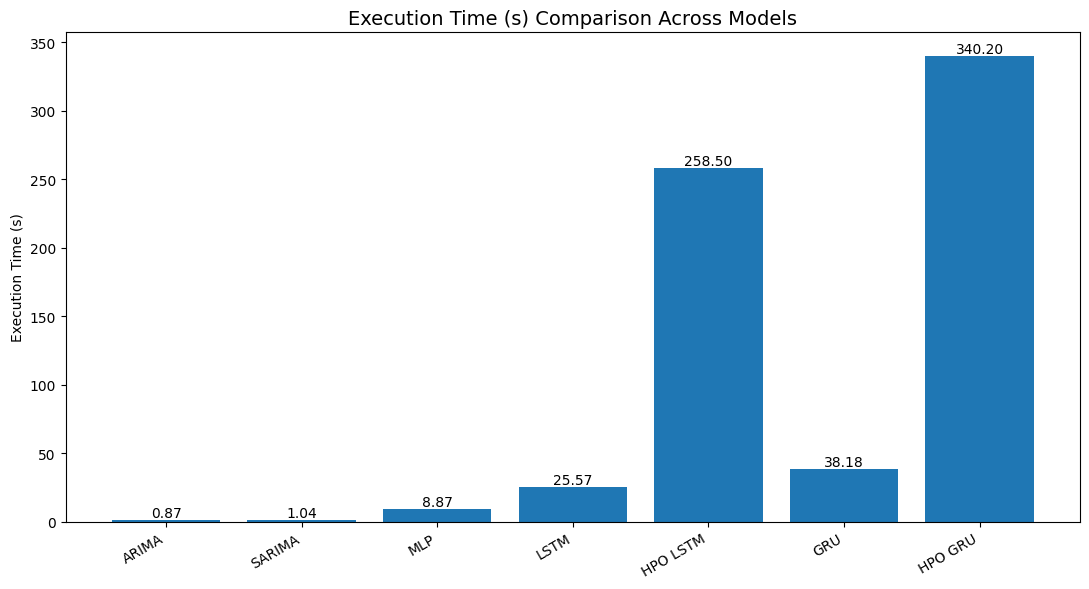

In [18]:
# Final Model Comparison Summary
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Safely converting a value to float. If the value is None, missing, or cannot be converted, return np.nan instead of raising an error.
def safe_float(x):
    try:
        return float(x)
    except:
        return np.nan

# Creating results array of evaluation metrics
results = [
    {"Model": "ARIMA",     "RMSE": arima_rmse,     "MAE": arima_mae,     "R²": arima_r2,     "Loss": safe_float(arima_loss),     "Execution Time (s)": safe_float(arima_time)},
    {"Model": "SARIMA",    "RMSE": sarima_rmse,    "MAE": sarima_mae,    "R²": sarima_r2,    "Loss": safe_float(sarima_loss),    "Execution Time (s)": safe_float(sarima_time)},
    {"Model": "MLP",       "RMSE": mlp_rmse,       "MAE": mlp_mae,       "R²": mlp_r2,       "Loss": safe_float(mlp_loss),       "Execution Time (s)": safe_float(mlp_time)},
    {"Model": "LSTM",      "RMSE": lstm_rmse,      "MAE": lstm_mae,      "R²": lstm_r2,      "Loss": safe_float(lstm_loss),      "Execution Time (s)": safe_float(lstm_time)},
    {"Model": "HPO LSTM",  "RMSE": lstm_hpo_rmse,  "MAE": lstm_hpo_mae,  "R²": lstm_hpo_r2,  "Loss": safe_float(lstm_hpo_loss),  "Execution Time (s)": safe_float(lstm_hpo_time)},
    {"Model": "GRU",       "RMSE": gru_rmse,       "MAE": gru_mae,       "R²": gru_r2,       "Loss": safe_float(gru_loss),       "Execution Time (s)": safe_float(gru_time)},
    {"Model": "HPO GRU",   "RMSE": gru_hpo_rmse,   "MAE": gru_hpo_mae,   "R²": gru_hpo_r2,   "Loss": safe_float(gru_hpo_loss),   "Execution Time (s)": safe_float(gru_hpo_time)},
]

# Converting the list of model metric dictionaries into a DataFrame and set 'Model' as the row index
comparison_df = pd.DataFrame(results).set_index("Model")


# Printing model comparison table
print("\n Final Model Comparison \n")
display(
    comparison_df
        .reset_index()
        .style
        .hide(axis="index")
        .format({
        "RMSE": "{:.4f}",
        "MAE": "{:.4f}",
        "R²": "{:.4f}",
        "Loss": "{:.4f}",
        "Execution Time (s)": "{:.2f}",
    })
)

# Output bar charts for each metric
metrics = ["RMSE", "MAE", "R²", "Loss", "Execution Time (s)"]

for metric in metrics:
    plt.figure(figsize=(11, 6))
    values = comparison_df[metric].values
    bars = plt.bar(comparison_df.index, values)

    plt.title(f"{metric} Comparison Across Models", fontsize=14)
    plt.ylabel(metric)
    plt.xticks(rotation=30, ha="right")

    for bar, val in zip(bars, values):
        label = "NaN" if np.isnan(val) else (f"{val:.2f}" if metric=="Execution Time (s)" else f"{val:.3f}")
        plt.text(bar.get_x()+bar.get_width()/2, bar.get_height(), label, ha="center", va="bottom")

    plt.tight_layout()
    plt.show()
